In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<ipython-input-52-a123706bdacb>:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(10,10,'Hubble Constant={:.2f}'.format(float(model_2.coef_)))


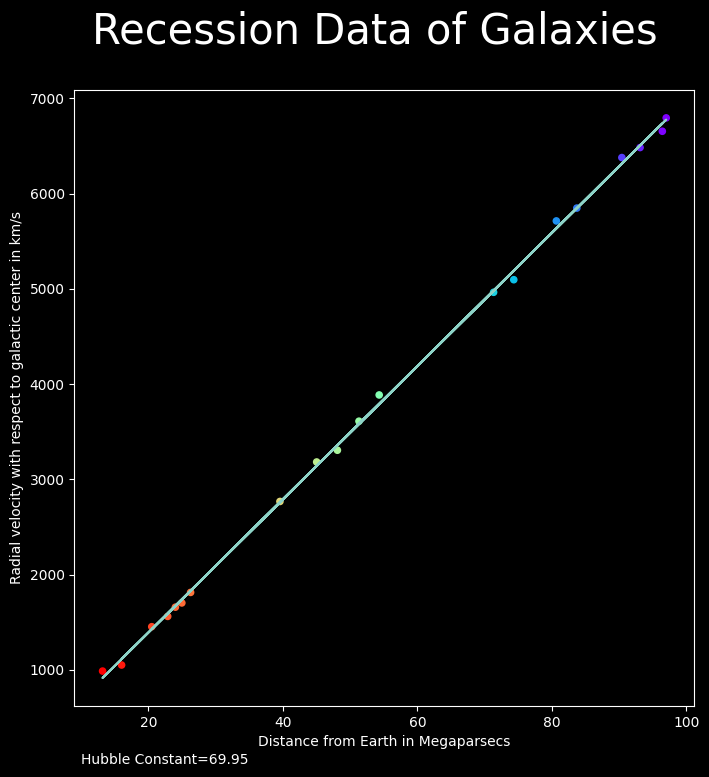

<ipython-input-52-a123706bdacb>:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(30,10,'Hubble Constant={:.2f}'.format(float(model_2_filtered_2.coef_)))


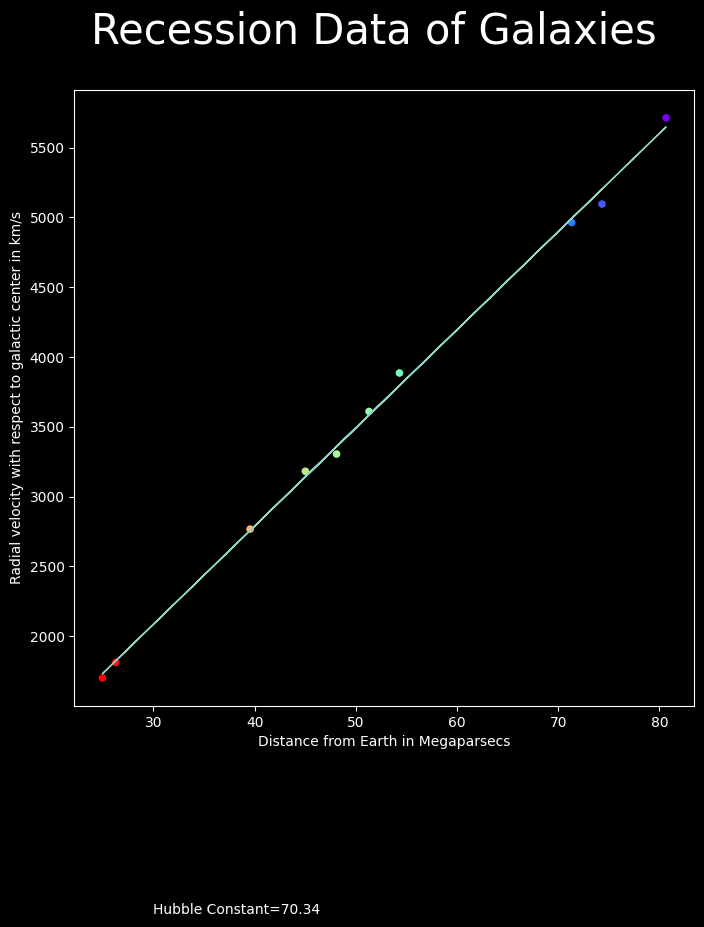

69.95392420993086
70.33972551516581


In [ ]:
data_2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/data_2.xlsx - Sheet1.csv')

data_2['Distance (Mpc)'] = pd.to_numeric(data_2['Distance (Mpc)'], errors='coerce')
data_2['Velocity (km/s)'] = pd.to_numeric(data_2['Velocity (km/s)'], errors='coerce')
data_2 = data_2.dropna(subset=['Distance (Mpc)','Velocity (km/s)'])

#assigning variables x and y for columns of data
x_2 = data_2['Distance (Mpc)']
y_2 = data_2['Velocity (km/s)']

#using parameters to take care of outliers
x_avg_2 = x_2.mean()
x_std_2 = x_2.std()
y_avg_2 = y_2.mean()
y_std_2 = y_2.std()

#lists to store non-outliers
x_2_filtered = []
y_2_filtered = []

#processing outliers
length_2 = len(x_2)
for i in range(length_2):
    if (x_2.iloc[i] <= x_avg_2 + x_std_2 and x_2.iloc[i] >= x_avg_2 - x_std_2 and
        y_2.iloc[i] <= y_avg_2 + y_std_2 and y_2.iloc[i] >= y_avg_2 - y_std_2):
        x_2_filtered.append(x_2.iloc[i])
        y_2_filtered.append(y_2.iloc[i])

#fitting the model with outliers for dataset 1
model_2 = LinearRegression()
model_2.fit(np.array(x_2).reshape(-1, 1), np.array(y_2))
y_predicted_2 = model_2.coef_ * x_2 + model_2.intercept_

#plotting data with outliers
plt.style.use("dark_background")
plt.figure(figsize = (8,8))
plt.scatter(x_2, y_2, c = x_2, cmap = 'rainbow_r', s=20)
plt.plot(x_2, y_predicted_2)
plt.suptitle("Recession Data of Galaxies", fontsize = 30)
plt.xlabel('Distance from Earth in Megaparsecs')
plt.ylabel('Radial velocity with respect to galactic center in km/s')
plt.text(10,10,'Hubble Constant={:.2f}'.format(float(model_2.coef_)))
plt.show()

#fitting the models without outliers for dataset 1
model_2_filtered_2 = LinearRegression()
model_2_filtered_2.fit(np.array(x_2_filtered).reshape(-1, 1), np.array(y_2_filtered))
y_predicted_filtered_2 = model_2_filtered_2.coef_ * x_2_filtered + model_2_filtered_2.intercept_

#plotting data without outliers
plt.style.use("dark_background")
plt.figure(figsize = (8,8))
plt.scatter(x_2_filtered, y_2_filtered, c = x_2_filtered, cmap = 'rainbow_r', s=20)
plt.plot(x_2_filtered, y_predicted_filtered_2, linewidth = 1)
plt.suptitle("Recession Data of Galaxies", fontsize = 30)
plt.xlabel('Distance from Earth in Megaparsecs')
plt.ylabel('Radial velocity with respect to galactic center in km/s')
plt.text(30,10,'Hubble Constant={:.2f}'.format(float(model_2_filtered_2.coef_)))
plt.show()

hubble_2 = model_2.coef_[0]
hubble_2_non = model_2_filtered_2.coef_[0]
print(hubble_2)
print(hubble_2_non)